=== MODEL EVALUATION METRICS ===
Root Mean Squared Error (RMSE): $81,083.40
R² Score: 0.4983


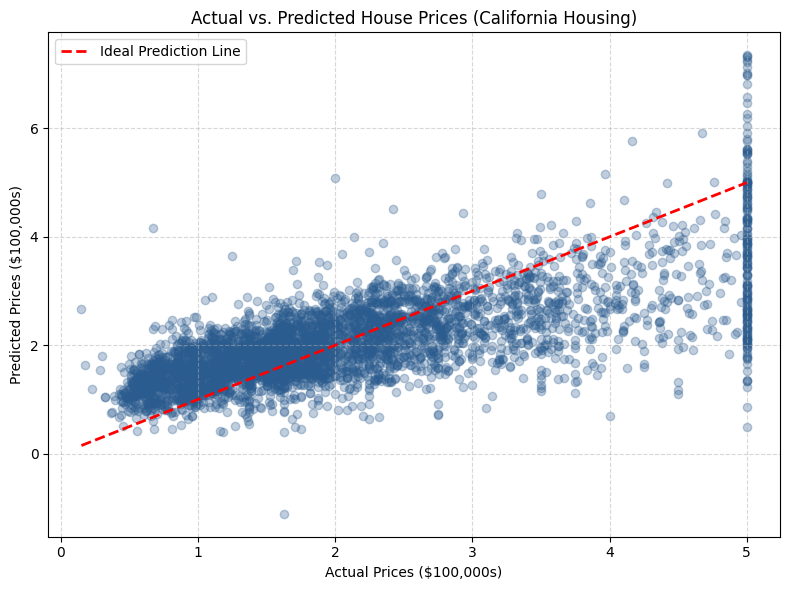

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. LOAD DATASET
california = fetch_california_housing(as_frame=True)
df = california.frame

# 2. SELECT 4 KEY FEATURES
# MedInc: Median income in block group
# AveRooms: Average number of rooms per household
# HouseAge: Median house age in block group
# AveOccup: Average number of household members
selected_features = ["MedInc", "AveRooms", "HouseAge", "AveOccup"]

X = df[selected_features]
y = df["MedHouseVal"]  # Target price in $100,000s

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. TRAIN LINEAR REGRESSION MODEL
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# 4. EVALUATE MODEL PERFORMANCE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MODEL EVALUATION METRICS ===")
print(f"Root Mean Squared Error (RMSE): ${rmse * 100000:,.2f}")
print(f"R² Score: {r2:.4f}")

# 5. PLOT PREDICTED VS. ACTUAL PRICES
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="#2b5c8f")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ideal Prediction Line",
)
plt.title("Actual vs. Predicted House Prices (California Housing)")
plt.xlabel("Actual Prices ($100,000s)")
plt.ylabel("Predicted Prices ($100,000s)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()